In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv('../data/processed/cleaned_salaries.csv')
print(f"Rows: {len(df):,}")

print(f"\nColumns:")
print(df.columns.tolist())
print(f"\nData types:")
print(df.dtypes)

Rows: 2,538

Columns:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size']

Data types:
work_year              int64
experience_level      object
employment_type       object
job_title             object
salary                 int64
salary_currency       object
salary_in_usd          int64
employee_residence    object
remote_ratio           int64
company_location      object
company_size          object
dtype: object


In [2]:
# Columns na TEXT pa — kailangan i-convert to numbers
cat_cols = ['experience_level', 'employment_type', 
            'company_size', 'company_location', 'job_title']

for col in cat_cols:
    print(f"\n{col}: {df[col].nunique()} unique values")
    print(df[col].unique())


experience_level: 4 unique values
['SE' 'MI' 'EN' 'EX']

employment_type: 4 unique values
['FT' 'CT' 'FL' 'PT']

company_size: 3 unique values
['L' 'S' 'M']

company_location: 66 unique values
['ES' 'US' 'CA' 'DE' 'GB' 'NG' 'IN' 'HK' 'NL' 'CH' 'CF' 'FR' 'FI' 'UA'
 'IE' 'IL' 'CO' 'SG' 'AU' 'SE' 'SI' 'MX' 'PT' 'RU' 'TH' 'GH' 'HR' 'BR'
 'EE' 'AM' 'BA' 'KE' 'LV' 'RO' 'PK' 'IT' 'PL' 'LT' 'AS' 'CR' 'IR' 'BS'
 'HU' 'AT' 'PR' 'GR' 'DK' 'PH' 'AR' 'BE' 'ID' 'TR' 'EG' 'AE' 'MY' 'HN'
 'CZ' 'JP' 'DZ' 'IQ' 'CN' 'NZ' 'CL' 'MD' 'LU' 'MT']

job_title: 91 unique values
['Principal Data Scientist' 'ML Engineer' 'Data Scientist'
 'Applied Scientist' 'Data Analyst' 'Data Modeler' 'Research Engineer'
 'Analytics Engineer' 'Business Intelligence Engineer'
 'Machine Learning Engineer' 'Data Strategist' 'Data Engineer'
 'Computer Vision Engineer' 'Data Quality Analyst'
 'Compliance Data Analyst' 'Data Architect'
 'Applied Machine Learning Engineer' 'AI Developer' 'Research Scientist'
 'Data Analytics Manager'

In [3]:
# Step 1 — Label Encoding
# Para sa columns na MAY ORDER

# experience_level: EN < MI < SE < EX
exp_map = {'EN': 0, 'MI': 1, 'SE': 2, 'EX': 3}
df['experience_encoded'] = df['experience_level'].map(exp_map)

# company_size: S < M < L
size_map = {'S': 0, 'M': 1, 'L': 2}
df['size_encoded'] = df['company_size'].map(size_map)

# Check
print("Experience encoding:")
print(df[['experience_level', 'experience_encoded']].drop_duplicates().sort_values('experience_encoded'))

print("\nSize encoding:")
print(df[['company_size', 'size_encoded']].drop_duplicates().sort_values('size_encoded'))

Experience encoding:
   experience_level  experience_encoded
13               EN                   0
1                MI                   1
0                SE                   2
58               EX                   3

Size encoding:
  company_size  size_encoded
1            S             0
3            M             1
0            L             2


In [4]:
# Step 2 — One-Hot Encoding
# Para sa columns na WALANG ORDER

df_encoded = pd.get_dummies(df, 
                             columns=['employment_type',
                                      'company_location',
                                      'job_title'],
                             drop_first=True)

print(f"Columns before: 9")
print(f"Columns after:  {len(df_encoded.columns)}")
print(f"\nNew columns sample:")
print([c for c in df_encoded.columns if 'employment' in c])

Columns before: 9
Columns after:  168

New columns sample:
['employment_type_FL', 'employment_type_FT', 'employment_type_PT']


In [5]:
# X = features (input sa ML model)
# y = target (huhulaan ng model)

# Columns na HINDI natin kailangan
drop_cols = ['experience_level',  # may encoded na
             'company_size',       # may encoded na
             'salary',             # local currency
             'salary_currency',    # hindi relevant
             'employee_residence'] # similar sa location

# I-drop ang hindi kailangan
X = df_encoded.drop(columns=drop_cols + ['salary_in_usd'])
y = df_encoded['salary_in_usd']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nFeatures: {X.columns.tolist()[:10]}...")

X shape: (2538, 162)
y shape: (2538,)

Features: ['work_year', 'remote_ratio', 'experience_encoded', 'size_encoded', 'employment_type_FL', 'employment_type_FT', 'employment_type_PT', 'company_location_AM', 'company_location_AR', 'company_location_AS']...


In [6]:
# I-drop ang columns na hindi kailangan
drop_cols = ['experience_level',   # may encoded na
             'company_size',        # may encoded na
             'salary',              # local currency
             'salary_currency',     # hindi relevant
             'employee_residence']  # similar sa location

# X = features (input sa model)
# y = target (huhulaan ng model)
X = df_encoded.drop(columns=drop_cols + ['salary_in_usd'])
y = df_encoded['salary_in_usd']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (2538, 162)
y shape: (2538,)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% = test
    random_state=42     # para reproducible
)

print(f"Training set:   {X_train.shape[0]:,} rows")
print(f"Testing set:    {X_test.shape[0]:,} rows")

Training set:   2,030 rows
Testing set:    508 rows


In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, \
                            mean_squared_error, r2_score
import numpy as np

print("Libraries installed")


Libraries installed


In [11]:
# Check muna
print(X_train.dtypes.value_counts())
print(f"\nMay infinite values? {np.isinf(X_train).any().any()}")
print(f"May NaN values? {X_train.isna().any().any()}")

bool     158
int64      4
Name: count, dtype: int64

May infinite values? False
May NaN values? False


In [16]:
# I-convert lahat ng bool columns → int (0 or 1)
X_train = X_train.astype(int)
X_test  = X_test.astype(int)

# Verify
print(X_train.dtypes.value_counts())
print(f"\nSample values:")
print(X_train.iloc[0, :5])

int32    162
Name: count, dtype: int64

Sample values:
work_year             2021
remote_ratio           100
experience_encoded       2
size_encoded             1
employment_type_FL       0
Name: 2438, dtype: int32


In [17]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print("LINEAR REGRESSION:")
print(f"MAE:  ${lr_mae:,.0f}")
print(f"RMSE: ${lr_rmse:,.0f}")
print(f"R²:   {lr_r2:.4f}")

LINEAR REGRESSION:
MAE:  $13,048,203,474,353
RMSE: $213,465,296,594,553
R²:   -12886106472687843328.0000


In [18]:
# Check yung y values
print("y_train sample:")
print(y_train.head(10))
print(f"\ny_train dtype: {y_train.dtype}")
print(f"y_train max: {y_train.max():,}")
print(f"y_train min: {y_train.min():,}")

# Check prediction
print(f"\nFirst 5 predictions:")
print(lr_pred[:5])

y_train sample:
2438     71786
2315    130026
157     105200
1622    275000
2217    200000
2083     49253
2388     33511
1242    155000
1918    128058
1967     84053
Name: salary_in_usd, dtype: int64

y_train dtype: int64
y_train max: 450,000
y_train min: 15,000

First 5 predictions:
[160619.5399857   85066.20126327 113878.72281493 157376.67329066
 155334.39879164]


In [19]:
# Fresh conversion + training — all in one
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, \
                            mean_squared_error, r2_score
import numpy as np

# Convert to int
X_train_int = X_train.astype(float)
X_test_int  = X_test.astype(float)

# Train
lr_model = LinearRegression()
lr_model.fit(X_train_int, y_train)

# Predict
lr_pred = lr_model.predict(X_test_int)

# Check predictions first
print("First 5 predictions:")
print(lr_pred[:5])

print("\nActual values:")
print(y_test.values[:5])

# Evaluate
lr_mae  = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_r2   = r2_score(y_test, lr_pred)

print(f"\nLINEAR REGRESSION:")
print(f"MAE:  ${lr_mae:,.0f}")
print(f"RMSE: ${lr_rmse:,.0f}")
print(f"R²:   {lr_r2:.4f}")

First 5 predictions:
[160619.5399857   85066.20126327 113878.72281493 157376.67329066
 155334.39879164]

Actual values:
[220000  57723 190000 150000 195000]

LINEAR REGRESSION:
MAE:  $13,048,203,474,353
RMSE: $213,465,296,594,553
R²:   -12886106472687843328.0000


In [20]:
# Manual MAE check
import numpy as np

# Compute manually
diff = y_test.values - lr_pred
print("Differences (first 5):")
print(diff[:5])

print(f"\nMax difference: {np.max(np.abs(diff)):,.0f}")
print(f"Min difference: {np.min(np.abs(diff)):,.0f}")

# Check if may outlier sa differences
print(f"\nAny infinite diff? {np.isinf(diff).any()}")
print(f"Any NaN diff? {np.isnan(diff).any()}")

# Manual MAE
manual_mae = np.mean(np.abs(diff))
print(f"\nManual MAE: ${manual_mae:,.0f}")

# Check y_test
print(f"\ny_test length: {len(y_test)}")
print(f"lr_pred length: {len(lr_pred)}")

Differences (first 5):
[ 59380.4600143  -27343.20126327  76121.27718507  -7376.67329066
  39665.60120836]

Max difference: 4,619,887,063,848,586
Min difference: 254

Any infinite diff? False
Any NaN diff? False

Manual MAE: $13,048,203,474,353

y_test length: 508
lr_pred length: 508


In [21]:
# Hanapin yung sobrang laki na prediction
diff_abs = np.abs(diff)

# Index ng pinakamalaking error
worst_idx = np.argmax(diff_abs)

print(f"Worst prediction index: {worst_idx}")
print(f"Actual salary:    ${y_test.values[worst_idx]:,.0f}")
print(f"Predicted salary: ${lr_pred[worst_idx]:,.0f}")
print(f"Difference:       ${diff_abs[worst_idx]:,.0f}")

# Tingnan kung may ibang sobrang laki
print(f"\nTop 5 worst predictions:")
worst_5 = np.argsort(diff_abs)[-5:]
for idx in worst_5:
    print(f"Actual: ${y_test.values[idx]:,.0f} | "
          f"Predicted: ${lr_pred[idx]:,.0f} | "
          f"Diff: ${diff_abs[idx]:,.0f}")

Worst prediction index: 65
Actual salary:    $120,000
Predicted salary: $4,619,887,063,968,586
Difference:       $4,619,887,063,848,586

Top 5 worst predictions:
Actual: $90,000 | Predicted: $56,497,671,708,871 | Diff: $56,497,671,618,871
Actual: $72,000 | Predicted: $56,497,671,708,871 | Diff: $56,497,671,636,871
Actual: $40,038 | Predicted: $913,780,217,332,343 | Diff: $913,780,217,292,305
Actual: $100,000 | Predicted: $981,591,101,982,245 | Diff: $981,591,101,882,245
Actual: $120,000 | Predicted: $4,619,887,063,968,586 | Diff: $4,619,887,063,848,586


In [22]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,    # 100 trees
    learning_rate=0.1,   # step size
    max_depth=6,         # depth ng bawat tree
    random_state=42
)

xgb_model.fit(X_train_int, y_train)

xgb_pred = xgb_model.predict(X_test_int)

xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_r2   = r2_score(y_test, xgb_pred)

print("XGBOOST:")
print(f"MAE:  ${xgb_mae:,.0f}")
print(f"RMSE: ${xgb_rmse:,.0f}")
print(f"R²:   {xgb_r2:.4f}")

# Check predictions
print(f"\nFirst 5 predictions vs actual:")
for i in range(5):
    print(f"Predicted: ${xgb_pred[i]:,.0f} | "
          f"Actual: ${y_test.values[i]:,.0f}")

XGBOOST:
MAE:  $36,514
RMSE: $46,583
R²:   0.3863

First 5 predictions vs actual:
Predicted: $160,533 | Actual: $220,000
Predicted: $76,926 | Actual: $57,723
Predicted: $108,265 | Actual: $190,000
Predicted: $255,679 | Actual: $150,000
Predicted: $160,533 | Actual: $195,000


In [23]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1        # use all CPU cores
)

rf_model.fit(X_train_int, y_train)
rf_pred = rf_model.predict(X_test_int)

rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)

print("RANDOM FOREST:")
print(f"MAE:  ${rf_mae:,.0f}")
print(f"RMSE: ${rf_rmse:,.0f}")
print(f"R²:   {rf_r2:.4f}")

# Compare both
print("\n=== MODEL COMPARISON ===")
print(f"{'Model':<20} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("-" * 50)
print(f"{'XGBoost':<20} ${xgb_mae:>9,.0f} ${xgb_rmse:>9,.0f} {xgb_r2:>8.4f}")
print(f"{'Random Forest':<20} ${rf_mae:>9,.0f} ${rf_rmse:>9,.0f} {rf_r2:>8.4f}")

RANDOM FOREST:
MAE:  $38,190
RMSE: $50,109
R²:   0.2899

=== MODEL COMPARISON ===
Model                       MAE       RMSE       R²
--------------------------------------------------
XGBoost              $   36,514 $   46,583   0.3863
Random Forest        $   38,190 $   50,109   0.2899


In [24]:
# Try better parameters
xgb_model_v2 = XGBRegressor(
    n_estimators=500,      # more trees
    learning_rate=0.05,    # smaller steps
    max_depth=4,           # shallower trees
    subsample=0.8,         # 80% of data per tree
    colsample_bytree=0.8,  # 80% of features per tree
    random_state=42
)

xgb_model_v2.fit(X_train_int, y_train,
                  eval_set=[(X_test_int, y_test)],
                  verbose=False)

xgb_v2_pred = xgb_model_v2.predict(X_test_int)

xgb_v2_mae  = mean_absolute_error(y_test, xgb_v2_pred)
xgb_v2_rmse = np.sqrt(mean_squared_error(y_test, xgb_v2_pred))
xgb_v2_r2   = r2_score(y_test, xgb_v2_pred)

print("=== MODEL COMPARISON ===")
print(f"{'Model':<25} {'MAE':>10} {'R²':>8}")
print("-" * 45)
print(f"{'XGBoost v1':<25} ${xgb_mae:>9,.0f} {xgb_r2:>8.4f}")
print(f"{'Random Forest':<25} ${rf_mae:>9,.0f} {rf_r2:>8.4f}")
print(f"{'XGBoost v2 (tuned)':<25} ${xgb_v2_mae:>9,.0f} {xgb_v2_r2:>8.4f}")

=== MODEL COMPARISON ===
Model                            MAE       R²
---------------------------------------------
XGBoost v1                $   36,514   0.3863
Random Forest             $   38,190   0.2899
XGBoost v2 (tuned)        $   36,619   0.3616


In [25]:
import pickle

# Save best model
with open('../models/xgb_salary_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

print("✅ Model saved to models/xgb_salary_model.pkl")

✅ Model saved to models/xgb_salary_model.pkl


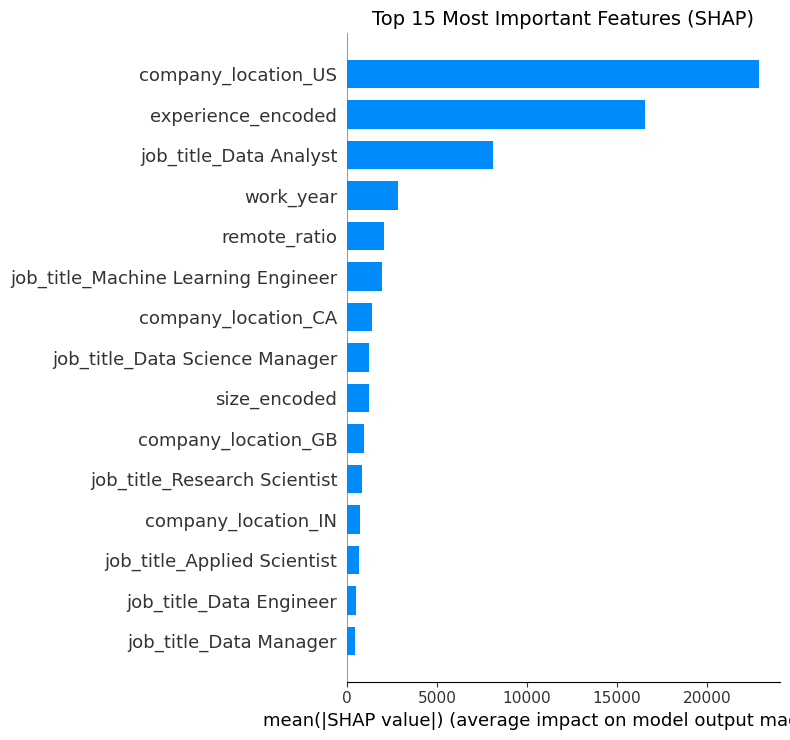

In [28]:
import shap
import matplotlib.pyplot as plt
# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_int)

# Plot feature importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, 
                  X_test_int, 
                  plot_type="bar",
                  max_display=15,
                  show=False)
plt.title('Top 15 Most Important Features (SHAP)', fontsize=14)
plt.tight_layout()
plt.show()

In [29]:
import json

# Save column names
columns = X_train_int.columns.tolist()

with open('../models/feature_columns.json', 'w') as f:
    json.dump(columns, f)

print(f"✅ Saved {len(columns)} column names!")

✅ Saved 162 column names!
